# Minimalizacja liczby fałszywych alarmów w monitorowaniu transakcji AML za pomocą porównania metod rule-based i uczenia maszynowego

**Autor:** Paweł Galla-Milewski (nr albumu 142095)  
**Studia:** Podyplomowe Studia Inżynieria danych – Big Data, SGH, Edycja 20  
**Promotor:** dr Mateusz Zawisza

Notebook stanowi aneks (załącznik z pełnym kodem źródłowym) do pracy końcowej pt.
*„Minimalizacja liczby fałszywych alarmów w monitorowaniu transakcji AML za pomocą porównania metod rule-based i uczenia maszynowego”*.
Zawiera: eksplorację danych (EDA), przeliczenie kwot na euro po kursach NBP, analizę rozkładu kwot,
implementację reguł rule-based i progów z przepisów UE i Polski, modele uczenia maszynowego
(regresja logistyczna, drzewo decyzyjne, Random Forest) oraz porównanie obu podejść.

**Dane:** zbiór HI-Small_Trans.csv z paczki *IBM Transactions for Anti Money Laundering (AML)*
(Kaggle, Altman i in., zbiór syntetyczny generowany przez IBM na potrzeby badań nad AML).
Kursy walut: API Narodowego Banku Polskiego (tabele A i B) oraz giełdy Binance (BTC/EUR);
kopia pobranych kursów jest w pliku kursy_walut.csv.


In [ ]:
# Importy

import os
import time
import json
import urllib.request as ul
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import sklearn

# narzedzia scikit-learn do podziału danych, standaryzacji, modeli i metryk oceny
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)

# żeby tabele pandas nie łamały się w polowie linijki przy wypisywaniu
pd.set_option('display.width', 120)

# spojna paleta kolorow do wszystkich wykresow w pracy
BLUE = '#3B6FA6'
ORANGE = '#D97642'
GRAY = '#9AA1A9'
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

# folder na rysunki do pracy
os.makedirs('rysunki', exist_ok=True)

# wersje bibliotek - dla powtarzalnosci wynikow
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__,
      "| matplotlib", matplotlib.__version__, "| scipy", scipy.__version__)

pandas 2.2.2 | numpy 1.26.4 | scikit-learn 1.5.1 | matplotlib 3.9.2 | scipy 1.13.1


## 1. Eksploracja danych (EDA)

In [ ]:
# Wczytanie danych
# Zbiór HI-Small_Trans.csv (IBM AML dataset, Kaggle) - ok. 5 mln transakcji.
sciezka = r"C:\Users\Asus\OneDrive\Dokumenty\BIG_DATA\praca_koncowa\HI-Small_Trans.csv"
if not os.path.exists(sciezka):
    sciezka = "HI-Small_Trans.csv"
df = pd.read_csv(sciezka)
print("Wymiar zbioru:", df.shape)

# sprawdzenie, czy dane wczytały się poprawnie
print(df.head().to_string())

Wymiar zbioru: (5078345, 11)
          Timestamp  From Bank    Account  To Bank  Account.1  Amount Received Receiving Currency  Amount Paid Payment Currency Payment Format  Is Laundering
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30          3697.34          US Dollar      3697.34        US Dollar   Reinvestment              0
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340             0.01          US Dollar         0.01        US Dollar         Cheque              0
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670         14675.57          US Dollar     14675.57        US Dollar   Reinvestment              0
3  2022/09/01 00:02         12  8000F5030       12  8000F5030          2806.97          US Dollar      2806.97        US Dollar   Reinvestment              0
4  2022/09/01 00:06         10  8000F5200       10  8000F5200         36682.97          US Dollar     36682.97        US Dollar   Reinvestment              0


In [ ]:
# Rozkład klasy docelowej (Is Laundering)
# To jest kluczowa informacja dla całej metodyki pracy: klasy są mocno niezbalansowane
print(df['Is Laundering'].value_counts())
print(df['Is Laundering'].value_counts(normalize=True))

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Is Laundering
0    0.998981
1    0.001019
Name: proportion, dtype: float64


In [19]:
# Braki danych i podstawowe informacje o zbiorze

print("Braki danych:")
print(df.isna().sum().sum(), "brakujacych wartosci w calym zbiorze")
print("Zduplikowane wiersze:", df.duplicated().sum())
print()
print("Zakres czasowy:", df['Timestamp'].min(), "-", df['Timestamp'].max())
print("Liczba unikalnych kont (nadawca):", df['Account'].nunique())
print("Liczba unikalnych kont (odbiorca):", df['Account.1'].nunique())
print("Liczba unikalnych bankow (nadawca):", df['From Bank'].nunique())

# liczba transakcji w kolejnych dniach
print("\nLiczba transakcji w kolejnych dniach:")
print(df['Timestamp'].str[:10].value_counts().sort_index().to_string())

Braki danych:
0 brakujacych wartosci w calym zbiorze
Zduplikowane wiersze: 9

Zakres czasowy: 2022/09/01 00:00 - 2022/09/18 16:18
Liczba unikalnych kont (nadawca): 496995
Liczba unikalnych kont (odbiorca): 420636
Liczba unikalnych bankow (nadawca): 30470

Liczba transakcji w kolejnych dniach:
Timestamp
2022/09/01    1114921
2022/09/02     754449
2022/09/03     207382
2022/09/04     207430
2022/09/05     482650
2022/09/06     482089
2022/09/07     482751
2022/09/08     482773
2022/09/09     654467
2022/09/10     208325
2022/09/11        396
2022/09/12        281
2022/09/13        184
2022/09/14        121
2022/09/15         46
2022/09/16         46
2022/09/17         23
2022/09/18         11


Wykres rozkładu klas: przy 5 073 168 transakcjach legalnych i 5 177 transakcjach prania
pieniędzy słupek klasy „pranie pieniędzy” w zwykłej skali jest praktycznie niewidoczny.

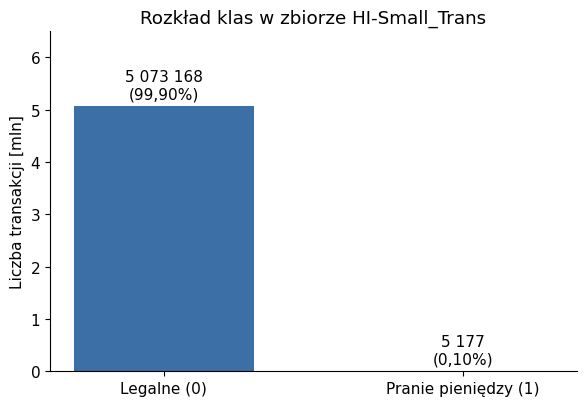

In [20]:
# Wykres rozkladu klas (Rysunek 2 w pracy) - zwykla skala osi Y
liczebnosc = df['Is Laundering'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(['Legalne (0)', 'Pranie pieniędzy (1)'], [liczebnosc[0] / 1e6, liczebnosc[1] / 1e6],
       color=[BLUE, ORANGE], width=0.6)
# etykiety nad slupkami: liczba transakcji i udzial w zbiorze
for i, v in enumerate([liczebnosc[0], liczebnosc[1]]):
    etykieta = f"{v:,}".replace(",", " ") + f"\n({v / liczebnosc.sum() * 100:.2f}%)".replace(".", ",")
    ax.text(i, v / 1e6 + 0.08, etykieta, ha='center', va='bottom')
ax.set_ylim(0, 6.5)
ax.set_ylabel('Liczba transakcji [mln]')
ax.set_title('Rozkład klas w zbiorze HI-Small_Trans')
fig.tight_layout()
plt.savefig('rysunki/rys02_rozklad_klas.png', dpi=200, bbox_inches='tight')
plt.show()

Is Laundering       0      1
Payment Format              
ACH             11.75  86.59
Cheque          36.74   6.26
Credit Card     26.08   3.98
Cash             9.67   2.09
Bitcoin          2.88   1.08
Reinvestment     9.48   0.00
Wire             3.39   0.00


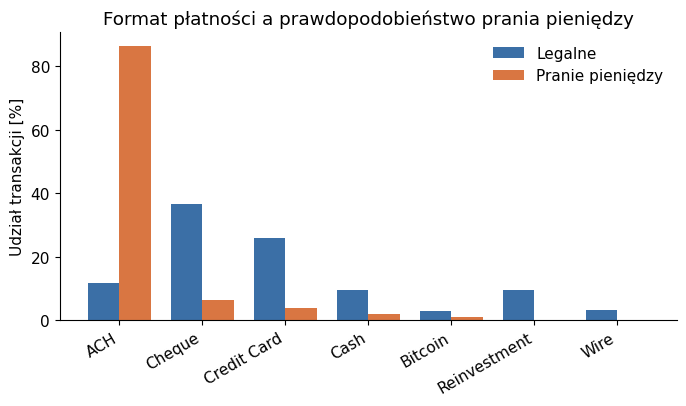

In [23]:
# Format platnosci a klasa docelowa
# Sprawdzamy, czy rozklad formatu platności (ACH, Cheque, Bitcoin itd.) różni sie  miedzy transakcjami legalnymi a nielegalnymi - normalize='columns'
#liczy udzial  procentowy wewnątrz kazdej klasy osobno, żeby porownanie bylo sprawiedliwe mimo że klasy maja zupelnie inną liczebnosc.
ct = pd.crosstab(df['Payment Format'], df['Is Laundering'], normalize='columns') * 100
ct = ct.sort_values(by=1, ascending=False)
print(ct.round(2))

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(ct))
w = 0.38
ax.bar(x - w/2, ct[0], width=w, label='Legalne', color=BLUE)
ax.bar(x + w/2, ct[1], width=w, label='Pranie pieniędzy', color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(ct.index, rotation=30, ha='right')
ax.set_ylabel('Udział transakcji [%]')
ax.set_title('Format płatności a prawdopodobieństwo prania pieniędzy')
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig('rysunki/rys03_format_platnosci.png', dpi=200, bbox_inches='tight')
plt.show()

**Obserwacja:** format płatności **ACH** jest silnie nadreprezentowany wśród
transakcji prania pieniędzy (ok. 87% przypadków vs ok. 12% w transakcjach legalnych).
Formaty *Wire* i *Reinvestment* w ogóle nie występują wśród oznaczonych przypadków
prania w tym zbiorze. To pierwsza przesłanka, że pojedyncze reguły oparte na kanale
płatności mogą mieć wpływ na predykcyjną — ale też istnieje ryzyko wysokiej liczby
fałszywych alarmów.

In [25]:
# Waluty transakcji: liczba transakcji i odsetek prania w każdej walucie
waluty = pd.crosstab(df['Payment Currency'], df['Is Laundering'])
waluty.columns = ['legalne', 'pranie']
waluty['udzial w zbiorze [%]'] = (waluty['legalne'] + waluty['pranie']) / len(df) * 100
waluty['odsetek prania [%]'] = waluty['pranie'] / (waluty['legalne'] + waluty['pranie']) * 100
print(waluty.sort_values('udzial w zbiorze [%]', ascending=False).round(3).to_string())
print("\nTransakcje walutowe (waluta zaplaty inna niz waluta otrzymania):",
      (df['Payment Currency'] != df['Receiving Currency']).sum())

                   legalne  pranie  udzial w zbiorze [%]  odsetek prania [%]
Payment Currency                                                            
US Dollar          1893260    1912                37.319               0.101
Euro               1166925    1372                23.005               0.117
Swiss Franc         234667     193                 4.625               0.082
Yuan                213568     184                 4.209               0.086
Shekel              192089      95                 3.784               0.049
Rupee               190035     167                 3.745               0.088
UK Pound            180606     132                 3.559               0.073
Yen                 155054     155                 3.056               0.100
Ruble               155045     133                 3.056               0.086
Bitcoin             146010      56                 2.876               0.038
Canadian Dollar     139914     128                 2.758               0.091

### 1a. Przeliczenie kwot na EUR po kursach NBP

Progi w przepisach AML są wyrażone w euro, a art. 5 ustawy o przeciwdziałaniu praniu pieniędzy
oraz finansowaniu terroryzmu nakazuje przeliczać kwoty według średniego kursu NBP obowiązującego
w dniu transakcji. Kursy pobieram z API NBP:

* **tabela A** (kursy średnie publikowane w każdy dzień roboczy) – 12 walut,
* **tabela B** (publikowana raz w tygodniu, w środy) – rial saudyjski i rubel rosyjski
  (NBP od 9 marca 2022 r. publikuje kurs rubla tylko w tabeli B).

Dla dni bez notowań (weekendy, a dla tabeli B dni między publikacjami) przyjmuję ostatni wcześniej
opublikowany kurs. NBP nie publikuje kursu bitcoina, dlatego kurs BTC/EUR pochodzi z giełdy Binance
(dzienny kurs zamknięcia). 


In [27]:
# Kody walut (ISO 4217) dla nazw walut uzytych w zbiorze
kody_walut = {'US Dollar': 'USD', 'Euro': 'EUR', 'Swiss Franc': 'CHF', 'Yuan': 'CNY',
              'Shekel': 'ILS', 'Rupee': 'INR', 'UK Pound': 'GBP', 'Yen': 'JPY',
              'Canadian Dollar': 'CAD', 'Australian Dollar': 'AUD', 'Mexican Peso': 'MXN',
              'Brazil Real': 'BRL', 'Saudi Riyal': 'SAR', 'Ruble': 'RUB', 'Bitcoin': 'BTC'}
# waluty z tabeli A NBP (kursy srednie z kazdego dnia roboczego)
waluty_tabela_a = ['USD', 'EUR', 'CHF', 'CNY', 'ILS', 'INR', 'GBP', 'JPY', 'CAD', 'AUD', 'MXN', 'BRL']
# waluty z tabeli B NBP (kursy publikowane raz w tygodniu, w srody)
waluty_tabela_b = ['SAR', 'RUB']

# zakres dat: transakcje sa z 1-18.09.2022; kursy pobieram od 25.08.2022, zeby dla 1.09 (i każdego dnia bez notowan) był dostepny ostatni wcześniej opublikowany kurs
data_od = '2022-08-25'
data_do = '2022-09-18'

# Stałe regulacyjne - progi z przepisow UE i Polski uzywane w całym notebooku
PROG_GIIF_EUR = 15_000      # art. 72 ust. 1 i art. 35 ust. 1 pkt 2 lit. a ustawy AML (PL)
PROG_AMLR_EUR = 10_000      # art. 19 ust. 1 lit. b i art. 80 rozporzadzenia AMLR 2024/1624 (od 10.07.2027)
PROG_KRYPTO_EUR = 1_000     # art. 35 ust. 1 pkt 2 lit. c ustawy AML, art. 19 ust. 3 AMLR
LIMIT_GOTOWKI_PLN = 15_000  # art. 19 ustawy Prawo przedsiebiorcow (platnosci miedzy firmami)

In [33]:
# Pobranie kursow z internetu: API NBP (tabele A i B) i gieldy Binance (bitcoin).
# Jesli nie ma dostepu do internetu - wczytanie zapisanej kopii z pliku kursy_walut.csv.
wiersze = []
try:
    # 1) tabela A NBP - wszystkie tabele z zakresu dat (jedna tabela na kazdy dzien roboczy)
    url = 'https://api.nbp.pl/api/exchangerates/tables/a/' + data_od + '/' + data_do + '/?format=json'
    response = ul.urlopen(url)
    json_data = response.read().decode("utf-8")
    tabele_a = json.loads(json_data)
    for tabela in tabele_a:
        for kurs in tabela['rates']:
            if kurs['code'] in waluty_tabela_a:
                wiersze.append({'data': tabela['effectiveDate'], 'kod': kurs['code'], 'kurs': kurs['mid'],
                                'jednostka': 'PLN', 'zrodlo': 'NBP ' + tabela['no']})

    # 2) tabela B NBP - rial saudyjski i rubel (osobne zapytanie dla kazdej waluty)
    for kod in waluty_tabela_b:
        url = ('https://api.nbp.pl/api/exchangerates/rates/b/' + kod + '/' + data_od + '/'
               + data_do + '/?format=json')
        response = ul.urlopen(url)
        dane_b = json.loads(response.read().decode("utf-8"))
        for kurs in dane_b['rates']:
            wiersze.append({'data': kurs['effectiveDate'], 'kod': kod, 'kurs': kurs['mid'],
                            'jednostka': 'PLN', 'zrodlo': 'NBP ' + kurs['no']})

    # 3) bitcoin - dzienne notowania BTC/EUR z gieldy Binance (25.08-18.09.2022)
    url = ('https://api.binance.com/api/v3/klines?symbol=BTCEUR&interval=1d'
           '&startTime=1661385600000&endTime=1663545599999')
    response = ul.urlopen(url)
    notowania = json.loads(response.read().decode("utf-8"))
    for swieca in notowania:
        dzien = pd.to_datetime(swieca[0], unit='ms').strftime('%Y-%m-%d')
        wiersze.append({'data': dzien, 'kod': 'BTC', 'kurs': float(swieca[4]),
                        'jednostka': 'EUR', 'zrodlo': 'Binance BTCEUR (zamkniecie dnia)'})

    kursy_zrodlowe = pd.DataFrame(wiersze)
    kursy_zrodlowe.to_csv('kursy_walut.csv', index=False)
    print("Kursy pobrane z API NBP i Binance i zapisane w pliku kursy_walut.csv")
except Exception as err:
    print("Nie udalo sie pobrac kursow z internetu - wczytuje zapisana kopie z pliku kursy_walut.csv")
    print("Powod:", err)
    kursy_zrodlowe = pd.read_csv('kursy_walut.csv')

print("Liczba kursow:", len(kursy_zrodlowe))
print(kursy_zrodlowe['kod'].value_counts().sort_index().to_string())

Kursy pobrane z API NBP i Binance i zapisane w pliku kursy_walut.csv
Liczba kursow: 235
kod
AUD    17
BRL    17
BTC    25
CAD    17
CHF    17
CNY    17
EUR    17
GBP    17
ILS    17
INR    17
JPY    17
MXN    17
RUB     3
SAR     3
USD    17


In [37]:
# Kurs "obowiazujacy w dniu transakcji": dla kazdego dnia ostatni kurs opublikowany w tym dniu lub wczesniej
kursy_zrodlowe['data'] = pd.to_datetime(kursy_zrodlowe['data'])
wszystkie_dni = pd.date_range(data_od, data_do, freq='D')
kursy_dzienne = pd.DataFrame(index=wszystkie_dni)
for kod in kursy_zrodlowe['kod'].unique():
    kursy_waluty = kursy_zrodlowe[kursy_zrodlowe['kod'] == kod].set_index('data')['kurs']
    kursy_dzienne[kod] = kursy_waluty
kursy_dzienne = kursy_dzienne.ffill()

# kurs w EUR: kurs waluty w PLN / kurs euro w PLN (tzw. kurs krzyzowy)
kursy_eur = pd.DataFrame(index=wszystkie_dni)
for kod in waluty_tabela_a + waluty_tabela_b:
    kursy_eur[kod] = kursy_dzienne[kod] / kursy_dzienne['EUR']
kursy_eur['BTC'] = kursy_dzienne['BTC']   # Binance podaje kurs bitcoina od razu w EUR

# kurs w PLN (potrzebny do limitu platnosci gotowkowych 15 000 zl z Prawa przedsiebiorcow)
kursy_pln = kursy_dzienne.copy()
kursy_pln['BTC'] = kursy_dzienne['BTC'] * kursy_dzienne['EUR']   # kurs BTC w EUR razy kurs EUR w PLN

print("Kursy z 1.09.2022 (Tabela 2):")
print(pd.DataFrame({'EUR za 1 jednostke': kursy_eur.loc['2022-09-01'],
                    'PLN za 1 jednostke': kursy_pln.loc['2022-09-01']}).round(6).to_string())
print(f"\n1 EUR = {kursy_dzienne.loc['2022-09-01', 'EUR'] / kursy_dzienne.loc['2022-09-01', 'USD']:.4f} USD (NBP, 1.09.2022)")

Kursy z 1.09.2022 (Tabela 2):
     EUR za 1 jednostke  PLN za 1 jednostke
AUD            0.680436            3.207100
BRL            0.192222            0.906000
BTC        20217.600000        95291.614080
CAD            0.755267            3.559800
CHF            1.020771            4.811200
CNY            0.144464            0.680900
EUR            1.000000            4.713300
GBP            1.155539            5.446400
ILS            0.296756            1.398700
INR            0.012536            0.059088
JPY            0.007156            0.033730
MXN            0.049307            0.232400
RUB            0.016549            0.078000
SAR            0.266883            1.257900
USD            0.996308            4.695900

1 EUR = 1.0037 USD (NBP, 1.09.2022)


In [39]:
# Przeliczenie kwot transakcji na EUR i PLN po kursie z dnia transakcji
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M')
df['day'] = df['Timestamp'].dt.floor('D')

df['kurs_eur'] = np.nan
df['kurs_pln'] = np.nan
for nazwa, kod in kody_walut.items():
    maska = df['Payment Currency'] == nazwa
    df.loc[maska, 'kurs_eur'] = df.loc[maska, 'day'].map(kursy_eur[kod])
    df.loc[maska, 'kurs_pln'] = df.loc[maska, 'day'].map(kursy_pln[kod])
print("Transakcje bez kursu:", df['kurs_eur'].isna().sum())

df['amount_eur'] = df['Amount Paid'] * df['kurs_eur']
df['amount_pln'] = df['Amount Paid'] * df['kurs_pln']

print("\nMediana kwoty w EUR (0 = legalne, 1 = pranie):")
print(df.groupby('Is Laundering')['amount_eur'].median().round(2).to_string())

# kontrola: w transakcjach walutowych ta sama kwota liczona od strony odbiorcy
fx = df[df['Payment Currency'] != df['Receiving Currency']].copy()
fx['kurs_eur_odbiorcy'] = np.nan
for nazwa, kod in kody_walut.items():
    maska = fx['Receiving Currency'] == nazwa
    fx.loc[maska, 'kurs_eur_odbiorcy'] = fx.loc[maska, 'day'].map(kursy_eur[kod])
roznica = (fx['Amount Received'] * fx['kurs_eur_odbiorcy'] / fx['amount_eur'] - 1).abs() * 100
print(f"\nTransakcje walutowe: {len(fx)} ({len(fx) / len(df):.2%} zbioru); roznica kwoty w EUR liczonej "
      f"od strony zaplaty i od strony odbiorcy - mediana {roznica.median():.1f}%")
del fx, roznica, maska

Transakcje bez kursu: 0

Mediana kwoty w EUR (0 = legalne, 1 = pranie):
Is Laundering
0     861.43
1    5672.63

Transakcje walutowe: 72170 (1.42% zbioru); roznica kwoty w EUR liczonej od strony zaplaty i od strony odbiorcy - mediana 13.7%


### 1b. Rozkład kwot w EUR

Kwoty transakcji opisuję miarami statystycznymi z zajęć: liczebność, suma, średnia, mediana,
kwartyle i rozstęp międzykwartylowy, percentyle 90 i 99, minimum i maksimum, odchylenie
standardowe, współczynnik zmienności, skośność i kurtoza – osobno dla transakcji legalnych
i prania pieniędzy. Dodatkowo sprawdzam, jaki odsetek transakcji przekracza progi z przepisów
(1 000, 10 000 i 15 000 EUR). Rozkład pokazują dwa wykresy w zwykłej skali: histogram
(Rysunek 4) i wykres pudełkowy (Rysunek 5); udział transakcji w przedziałach kwot podaje tabela w komórce poniżej.

In [41]:
# Miary opisujace rozklad kwot w EUR - osobno dla transakcji legalnych i prania pieniedzy (Tabela 3 w pracy)
kwoty_legalne = df.loc[df['Is Laundering'] == 0, 'amount_eur']
kwoty_pranie = df.loc[df['Is Laundering'] == 1, 'amount_eur']

miary = {}
for nazwa, kwoty in [('legalne', kwoty_legalne), ('pranie', kwoty_pranie)]:
    n, min_max, srednia, wariancja, skosnosc, kurtoza = scipy.stats.describe(kwoty)
    odchylenie = wariancja ** 0.5
    q1, mediana, q3, p90, p99 = np.percentile(kwoty, [25, 50, 75, 90, 99])
    miary[nazwa] = {
        'liczba transakcji': n,
        'suma [mln EUR]': kwoty.sum() / 1e6,
        'srednia': srednia,
        'mediana': mediana,
        'Q1 (kwartyl 25%)': q1,
        'Q3 (kwartyl 75%)': q3,
        'rozstep miedzykwartylowy (IQR)': q3 - q1,
        'percentyl 90': p90,
        'percentyl 99': p99,
        'minimum': min_max[0],
        'maksimum': min_max[1],
        'odchylenie standardowe': odchylenie,
        'wspolczynnik zmiennosci [%]': odchylenie / srednia * 100,
        'skosnosc': skosnosc,
        'kurtoza': kurtoza,
        'powyzej 1 000 EUR [%]': (kwoty > PROG_KRYPTO_EUR).mean() * 100,
        'powyzej 10 000 EUR [%]': (kwoty > PROG_AMLR_EUR).mean() * 100,
        'powyzej 15 000 EUR [%]': (kwoty > PROG_GIIF_EUR).mean() * 100}
tabela_miar = pd.DataFrame(miary)
print(tabela_miar.to_string(float_format='{:,.2f}'.format))

                                         legalne            pranie
liczba transakcji                   5,073,168.00          5,177.00
suma [mln EUR]                      1,721,503.29         26,689.84
srednia                               339,334.97      5,155,464.87
mediana                                   861.43          5,672.63
Q1 (kwartyl 25%)                          152.36          2,041.19
Q3 (kwartyl 75%)                        5,142.54         12,859.88
rozstep miedzykwartylowy (IQR)          4,990.18         10,818.69
percentyl 90                           34,759.90         17,788.57
percentyl 99                        3,026,187.84     14,756,886.36
minimum                                     0.00              0.33
maksimum                       29,211,795,208.28 16,456,909,110.44
odchylenie standardowe             23,496,817.11    233,348,228.84
wspolczynnik zmiennosci [%]             6,924.37          4,526.23
skosnosc                                  621.35             6

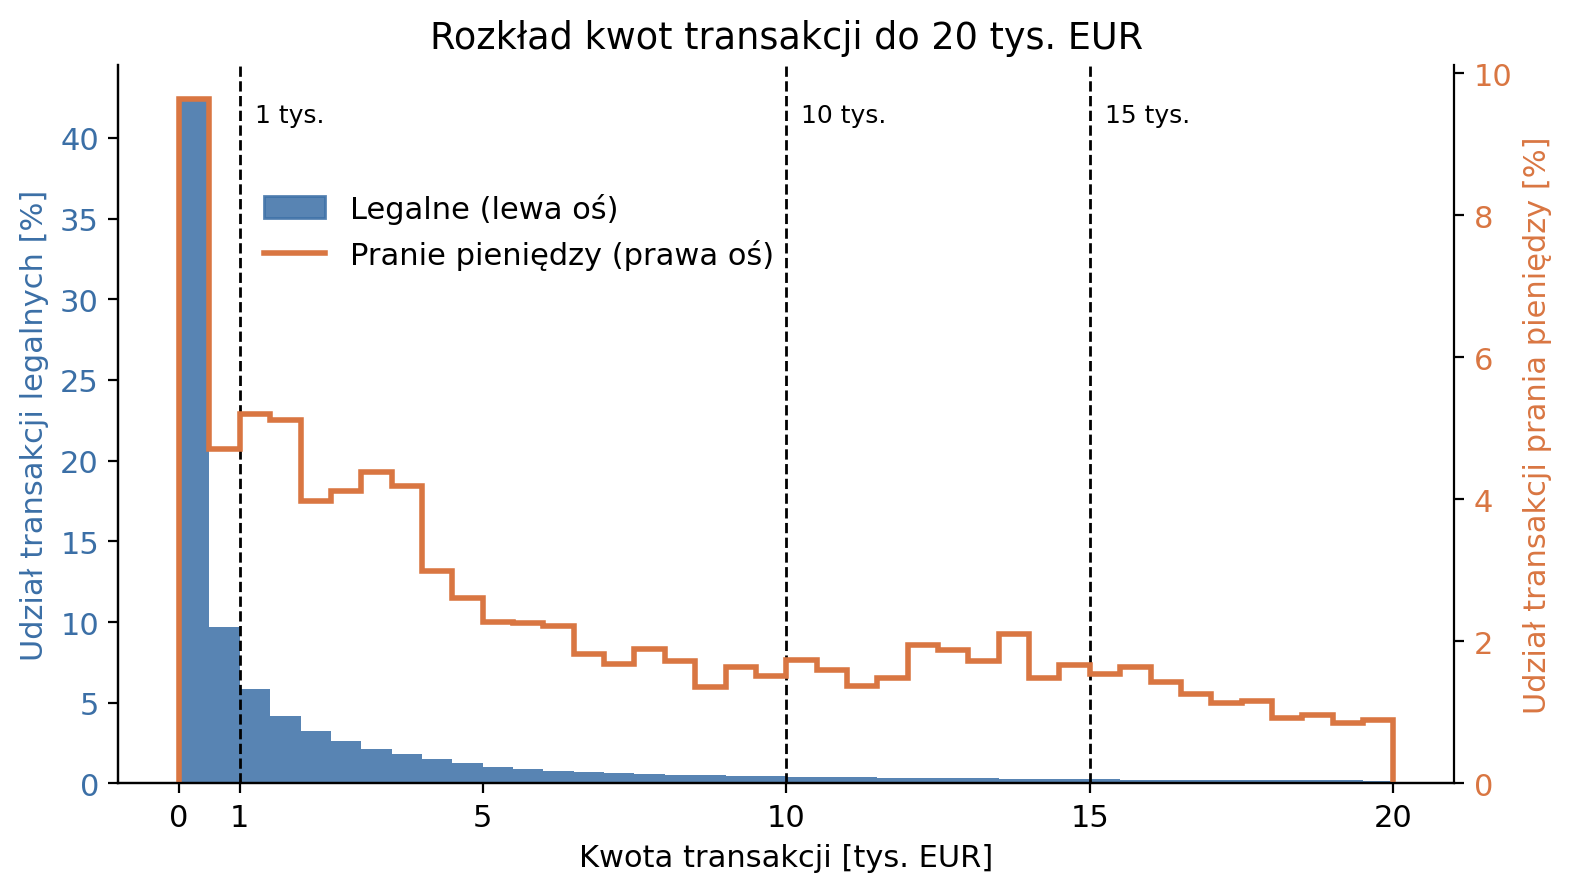

Poza wykresem (kwota > 20 tys. EUR): 13.2% transakcji legalnych, 5.9% transakcji prania


In [ ]:
# Histogram kwot w EUR (Rysunek 4 w pracy) - jeden wykres z dwiema osiami Y, bo klasy maja rozna liczebnosc:
# lewa os - transakcje legalne (slupki), prawa os - pranie pieniedzy (linia).
# Zakres 0-20 tys. EUR, w ktorym leżą progi z przepisów (1, 10 i 15 tys. EUR).
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
granica = 20_000
przedzialy_hist = np.arange(0, granica / 1000 + 0.5, 0.5)   # slupki co 500 EUR (0,5 tys.)
legalne_do_granicy = kwoty_legalne[kwoty_legalne <= granica] / 1000
pranie_do_granicy = kwoty_pranie[kwoty_pranie <= granica] / 1000

fig, ax1 = plt.subplots(figsize=(8, 4.6))
# lewa os: transakcje legalne (slupki)
ax1.hist(legalne_do_granicy, bins=przedzialy_hist, color=BLUE, alpha=0.85,
         weights=np.ones(len(legalne_do_granicy)) / len(kwoty_legalne) * 100)
ax1.set_ylabel('Udział transakcji legalnych [%]', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_xlabel('Kwota transakcji [tys. EUR]')
ax1.set_title('Rozkład kwot transakcji do 20 tys. EUR')
# prawa os: pranie pieniedzy (linia - histogram rysowany sama obwiednia)
ax2 = ax1.twinx()
ax2.hist(pranie_do_granicy, bins=przedzialy_hist, color=ORANGE, histtype='step', linewidth=2,
         weights=np.ones(len(pranie_do_granicy)) / len(kwoty_pranie) * 100)
ax2.set_ylabel('Udział transakcji prania pieniędzy [%]', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.spines['right'].set_visible(True)
# progi z przepisow
for prog in [1, 10, 15]:
    ax1.axvline(prog, color='black', linestyle='--', linewidth=1)
    ax1.text(prog + 0.25, ax1.get_ylim()[1] * 0.92, f"{prog} tys.", fontsize=9)
ax1.set_xticks([0, 1, 5, 10, 15, 20])
ax1.legend(handles=[Patch(color=BLUE, alpha=0.85, label='Legalne (lewa oś)'),
                    Line2D([], [], color=ORANGE, linewidth=2, label='Pranie pieniędzy (prawa oś)')],
           frameon=False, loc='upper center', bbox_to_anchor=(0.30, 0.86))
fig.tight_layout()
plt.savefig('rysunki/rys04_histogram_kwot.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Poza wykresem (kwota > 20 tys. EUR): {(kwoty_legalne > granica).mean():.1%} transakcji legalnych, "
      f"{(kwoty_pranie > granica).mean():.1%} transakcji prania")

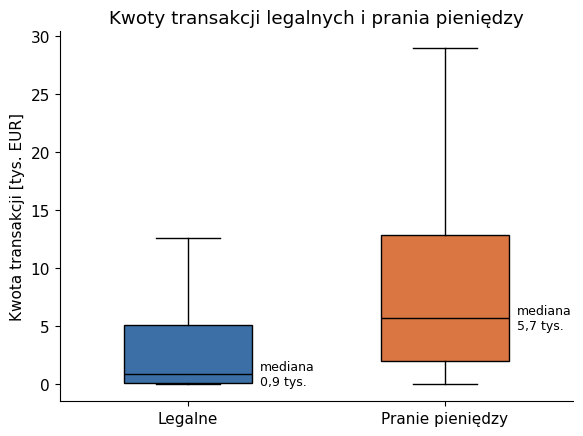

In [ ]:
# Wykres pudełkowy kwot w EUR (Rysunek 5 w pracy) - bez wartości odstających
fig, ax = plt.subplots(figsize=(6, 4.5))
wykres = ax.boxplot([kwoty_legalne / 1000, kwoty_pranie / 1000], showfliers=False,
                    patch_artist=True, widths=0.5)
for pudelko, kolor in zip(wykres['boxes'], [BLUE, ORANGE]):
    pudelko.set_facecolor(kolor)
for linia in wykres['medians']:
    linia.set_color('black')
# podpisy median obok boxów
for i, kwoty in enumerate([kwoty_legalne, kwoty_pranie]):
    ax.text(i + 1.28, kwoty.median() / 1000, "mediana\n" + f"{kwoty.median() / 1000:.1f}".replace('.', ',') + " tys.",
            va='center', fontsize=9)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Legalne', 'Pranie pieniędzy'])
ax.set_ylabel('Kwota transakcji [tys. EUR]')
ax.set_title('Kwoty transakcji legalnych i prania pieniędzy')
fig.tight_layout()
plt.savefig('rysunki/rys05_boxplot_kwot.png', dpi=200, bbox_inches='tight')
plt.show()

In [45]:
# Udzial transakcji w przedziałach kwot wyznaczonych przez progi z przepisow (tylko tabela - w pracy bez osobnego wykresu)
przedzialy = [0, PROG_KRYPTO_EUR, PROG_AMLR_EUR, PROG_GIIF_EUR, np.inf]
etykiety = ['do 1 tys.', '1–10 tys.', '10–15 tys.', '15 tys. i więcej']
df['przedzial_kwoty'] = pd.cut(df['amount_eur'], bins=przedzialy, labels=etykiety, right=False)
udzialy = pd.crosstab(df['przedzial_kwoty'], df['Is Laundering'], normalize='columns') * 100
odsetek_prania = df.groupby('przedzial_kwoty', observed=False)['Is Laundering'].mean() * 100
print(pd.DataFrame({'legalne [%]': udzialy[0], 'pranie [%]': udzialy[1],
                    'odsetek prania w przedziale [%]': odsetek_prania}).round(3).to_string())

                  legalne [%]  pranie [%]  odsetek prania w przedziale [%]
przedzial_kwoty                                                           
do 1 tys.              52.091      14.352                            0.028
1–10 tys.              29.169      50.956                            0.178
10–15 tys.              3.327      16.998                            0.519
15 tys. i więcej       15.413      17.694                            0.117


**Obserwacja:** rozkład kwot jest skrajnie prawostronnie skośny. Średnia kwota transakcji
legalnej (ok. 339 tys. EUR) jest blisko 400 razy wyższa od mediany (861 EUR), bo nieliczne transakcje
sięgają miliardów EUR (maksimum 29,2 mld EUR); skośność wynosi 621, a współczynnik zmienności
przekracza 6 900%. Do opisu typowej transakcji lepiej nadają się więc mediana i kwartyle niż średnia.
Transakcje prania są typowo większe (mediana 5 673 EUR wobec 861 EUR; Q3 12 860 EUR wobec
5 143 EUR), a połowa z nich mieści się między 2 041 a 12 860 EUR. W przedziale 10–15 tys. EUR, tuż
poniżej progu 15 000 EUR z ustawy AML, jest 17,0% transakcji prania i tylko 3,3% transakcji
legalnych – odsetek prania w tym przedziale (0,52%) jest pięciokrotnie wyższy niż w całym zbiorze
(0,10%). Kwotę powyżej 15 000 EUR ma 15,4% transakcji legalnych i 17,7% transakcji prania.

## 2. Feature engineering (cechy strukturalne i częstotliwościowe)

In [ ]:
# Przygotowanie cech: podstawowe + strukturalne/czestotliwosciowe (hipoteza H3)
# Cel: obok prostych cech statycznych (kwota, ten sam bank, waluta, format platnosci) dodac cechy
# opisujace zachowanie konta w czasie - bo pranie pieniedzy czesto objawia sie wzorcem (duzo transakcji w krotkim
# czasie, rozsylanie do wielu odbiorcow itd.
# (Timestamp zamieniony na date i dzien transakcji 'day'
# ujednolicenie nazw kolumn kont - oryginalne "Account"/"Account.1" nie mowia które konto jest nadawca a które odbiorca
df = df.rename(columns={'Account': 'From Account', 'Account.1': 'To Account'})

# proste cechy binarne policzone dla pojedynczej transakcji
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype(int)
df['same_currency'] = (df['Payment Currency'] == df['Receiving Currency']).astype(int)
df['amount_log'] = np.log1p(df['amount_eur'])  # kwota w EUR (sekcja 1a); log1p bo rozklad kwot jest mocno skosny
df['hour'] = df['Timestamp'].dt.hour
df['is_ach'] = (df['Payment Format'] == 'ACH').astype(int)
df['is_cheque'] = (df['Payment Format'] == 'Cheque').astype(int)
df['is_bitcoin'] = (df['Payment Format'] == 'Bitcoin').astype(int)

df['hour_bucket'] = df['Timestamp'].dt.floor('h')
# Cechy czestotliwosciowe liczą sie przez groupby().transform()

# Ustalam czestotliwosc: liczbe transakcji tego samego konta w tej samej godzinie zegarowej
# typowy sygnał AML przy regułach rule-based: dużo transakcji w krótkim czasie
df['velocity_1h'] = df.groupby(['From Account', 'hour_bucket'])['From Account'].transform('count')
# fan-out: liczba unikalnych odbiorcow danego konta w danym dniu
df['fanout_1d'] = df.groupby(['From Account', 'day'])['To Account'].transform('nunique')
# fan-in: liczba unikalnych nadawcow do danego konta w danym dniu
#  "zbieranie" srodkow z wielu kont - drugi koniec schematu fan-out)
df['fanin_1d'] = df.groupby(['To Account', 'day'])['From Account'].transform('nunique')
# aktywnosc konta - calkowita liczba transakcji jako nadawca (w calym zbiorze)
df['account_activity'] = df.groupby('From Account')['From Account'].transform('count')
# odchylenie kwoty od typowej kwoty danego konta (z-score wewnatrz konta) - pojedyncza duża transakcja może byc normalna dla jednego konta i bardzo nietypowa dla innego, wiec liczymy odchylenie wzgledem własna historii konta,
# a nie wzgledem calego zbioru (kwoty w EUR, zeby konto płacące w kilku walutach  nie mialo sztucznie zawyżonego odchylenia)
grp = df.groupby('From Account')['amount_eur']
acc_mean = grp.transform('mean')
acc_std = grp.transform('std').fillna(0)
df['amount_zscore'] = np.where(acc_std > 0, (df['amount_eur'] - acc_mean) / acc_std, 0)
del grp, acc_mean, acc_std

print("Cechy dodane. Liczba kolumn:", df.shape[1])
print(df[['amount_log','velocity_1h','fanout_1d','fanin_1d','account_activity','amount_zscore']].describe().round(2))

Cechy dodane. Liczba kolumn: 30
       amount_log  velocity_1h   fanout_1d    fanin_1d  account_activity  amount_zscore
count  5078345.00   5078345.00  5078345.00  5078345.00        5078345.00     5078345.00
mean         6.93        42.99      465.06        2.23           8256.83          -0.00
std          2.84       178.44     1935.31        9.65          33171.24           0.95
min          0.00         1.00        1.00        1.00              1.00          -6.00
25%          5.03         2.00        1.00        1.00             20.00          -0.42
50%          6.76         2.00        2.00        2.00             42.00          -0.19
75%          8.55         4.00        4.00        2.00             80.00           0.00
max         24.10      2829.00    12538.00      539.00         168672.00         199.17


In [49]:
# Transakcja zwrotna (round-trip) tego samego dnia
# Klasyczny schemat AML: pieniądze wracaja tego samego dnia do nadawcy (czesto przez posredni rachunek) - probujemy to wykryc, sprawdzajac czy dla danej  transakcji A->B istnieje tego samego dnia takze transakcja B->A.
pairs_today = df[['From Account', 'To Account', 'day']].drop_duplicates()
# budujemy klucz tekstowy "nadawca|odbiorca|dzien" dla kazdej pary kont z danego dnia
pairs_today['key'] = pairs_today['From Account'] + '|' + pairs_today['To Account'] + '|' + pairs_today['day'].astype(str)
# dla kazdej transakcji budujemy klucz ODWROTNY (czy istnieje transakcja w druga strone)
reverse_key = df['To Account'] + '|' + df['From Account'] + '|' + df['day'].astype(str)
existing_keys = set(pairs_today['key'])
# jesli odwrotny klucz istnieje w zbiorze par z danego dnia - to jest round-trip
df['round_trip'] = reverse_key.isin(existing_keys).astype(int)

# zwolnienie pamieci po duzych obiektach pomocniczych
del pairs_today, reverse_key, existing_keys
import gc; gc.collect()

# szybkie sprawdzenie: czy srednie wartosci cech faktycznie roznia sie miedzy klasa legalna a nielegalna
print(df.groupby('Is Laundering')[['same_bank','amount_log','velocity_1h','fanout_1d',
                                    'account_activity','amount_zscore','round_trip']].mean().T)

Is Laundering               0             1
same_bank            0.136252      0.019896
amount_log           6.928385      8.503345
velocity_1h         42.973061     61.356191
fanout_1d          464.857754    665.724165
account_activity  8253.273030  11741.024532
amount_zscore       -0.000159      0.155449
round_trip           0.116726      0.031679


## 3. Reguły rule-based (podejście eksperckie)

Zdefiniowano 5 reguł typowych dla systemów monitorowania transakcji w bankach
(por. rozdz. 2.1 pracy): duża pojedyncza kwota, structuring (kwoty tuż poniżej progu
z przepisów AML), wysoka częstotliwość transakcji (velocity), rozproszenie środków
(fan-out) oraz kanał wysokiego ryzyka. Reguły kwotowe R1 i R2 liczone są na kwotach w EUR
(sekcja 1a), a przedział reguły R2 odnosi się do progu 15 000 EUR z polskiej ustawy AML
(art. 72 – transakcje ponadprogowe zgłaszane do GIIF, art. 35 – środki bezpieczeństwa
finansowego przy transakcjach okazjonalnych).

In [51]:
# Implementacja 5 regul rule-based - typowe warunki, jakie stosuje sie w praktyce nadzorczej. 
#Kazda reguła to osobna kolumna 0/1,a RULE_ALERT to połączenie wszystkich pięciu operatorem OR (transakcja generuje alert, jesli spełnia 1 regule).
# Kwoty w regulach R1 i R2 sa w EUR (sekcja 1a), a prog w R2 pochodzi z polskiej ustawy AML.
amt_p99 = df['amount_eur'].quantile(0.99)
print(f"Prog R1 (99. percentyl kwoty w EUR): {amt_p99:,.2f} EUR")

# R1: nietypowo duża kwota (powyzej 99. percentyla kwot w EUR w calym zbiorze)
df['R1_duza_kwota']    = (df['amount_eur'] > amt_p99).astype('int8')
# R2: structuring - kwota tuż poniżej progu 15 000 EUR z ustawy AML (art. 72: transakcje ponadprogowe zglaszane do GIIF, art. 35: srodki bezpieczenstwa finansowego przy transakcjach okazjonalnych).
# Przedzial 80-100% progu = [12 000, 15 000) EUR
df['R2_structuring']   = ((df['amount_eur'] >= 0.8 * PROG_GIIF_EUR) & (df['amount_eur'] < PROG_GIIF_EUR)).astype('int8')
# R3: wysoka częstotliwoćś transakcji tego samego konta w ciagu godziny
df['R3_velocity']      = (df['velocity_1h'] >= 10).astype('int8')
# R4: rozproszenie środkow do wielu różnych odbiorców w ciagu jednego dnia
df['R4_fanout']        = (df['fanout_1d'] >= 20).astype('int8')
# R5: ryzykowny kanal platnosci (ACH) w polaczeniu z transakcja miedzybankową 
# (na podstawie obserwacji z EDA - ACH jest silnie nadreprezentowany w klasie 1)
df['R5_kanal_ryzyka']  = ((df['is_ach'] == 1) & (df['same_bank'] == 0)).astype('int8')

rule_cols = ['R1_duza_kwota','R2_structuring','R3_velocity','R4_fanout','R5_kanal_ryzyka']
df['RULE_ALERT'] = (df[rule_cols].sum(axis=1) > 0).astype('int8')

# pomocnicza funkcja do liczenia precision/recall/F1 z macierzy pomyłek, bo chcemy oceniać zarówno pojedyncze reguły, jak i ich połączenie.

def metrics(pred, y, name):
    tp = ((pred==1)&(y==1)).sum(); fp = ((pred==1)&(y==0)).sum()
    fn = ((pred==0)&(y==1)).sum(); tn = ((pred==0)&(y==0)).sum()
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    print(f"{name:20s} | alerty={pred.sum():8d} | TP={tp:5d} FP={fp:8d} FN={fn:5d} | "
          f"precision={precision:.4f} recall={recall:.4f} F1={f1:.4f}")
    return dict(regula=name, alerty=int(pred.sum()), TP=int(tp), FP=int(fp),
                precision=precision, recall=recall, f1=f1)

# ocena każdej reguły osobno oraz ich połączenia - na całym bziorze
y = df['Is Laundering']
wyniki_regul = [metrics(df[c], y, c) for c in rule_cols]
wyniki_regul.append(metrics(df['RULE_ALERT'], y, 'RULE_ALERT (OR)'))

Prog R1 (99. percentyl kwoty w EUR): 3,031,131.75 EUR
R1_duza_kwota        | alerty=   50784 | TP=  100 FP=   50684 FN= 5077 | precision=0.0020 recall=0.0193 F1=0.0036
R2_structuring       | alerty=   91967 | TP=  559 FP=   91408 FN= 4618 | precision=0.0061 recall=0.1080 F1=0.0115
R3_velocity          | alerty=  459775 | TP=  633 FP=  459142 FN= 4544 | precision=0.0014 recall=0.1223 F1=0.0027
R4_fanout            | alerty=  450978 | TP=  633 FP=  450345 FN= 4544 | precision=0.0014 recall=0.1223 F1=0.0028
R5_kanal_ryzyka      | alerty=  515885 | TP= 4381 FP=  511504 FN=  796 | precision=0.0085 recall=0.8462 F1=0.0168
RULE_ALERT (OR)      | alerty= 1091481 | TP= 5040 FP= 1086441 FN=  137 | precision=0.0046 recall=0.9735 F1=0.0092


In [55]:
# Pokrycie alertów: jaka część alertów danej reguly jest "unikalna" (nie wygenerowalaby jej żadna
# inna regula), a jaka pokrywa sie z alertami innych regul - sprawdzam czy reguły nie dubluja sie nawzajem
for c in rule_cols:
    inne = df[[r for r in rule_cols if r != c]].sum(axis=1) > 0
    alerty_c = df[c] == 1
    print(f"{c:16s} | unikalne: {(alerty_c & ~inne).sum() / alerty_c.sum():6.1%} | "
          f"pokrywajace sie z inna regula: {(alerty_c & inne).sum() / alerty_c.sum():6.1%}")
oba = (df['R3_velocity'] == 1) & (df['R4_fanout'] == 1)
print(f"\nR3 i R4 jednoczesnie: {oba.sum()} transakcji = {oba.sum() / df['R3_velocity'].sum():.1%} alertow R3 "
      f"i {oba.sum() / df['R4_fanout'].sum():.1%} alertow R4")
del inne, alerty_c, oba

R1_duza_kwota    | unikalne:  77.4% | pokrywajace sie z inna regula:  22.6%
R2_structuring   | unikalne:  82.8% | pokrywajace sie z inna regula:  17.2%
R3_velocity      | unikalne:   1.9% | pokrywajace sie z inna regula:  98.1%
R4_fanout        | unikalne:   0.3% | pokrywajace sie z inna regula:  99.7%
R5_kanal_ryzyka  | unikalne:  97.2% | pokrywajace sie z inna regula:   2.8%

R3 i R4 jednoczesnie: 449459 transakcji = 97.8% alertow R3 i 99.7% alertow R4


**Obserwacja:** pojedyncze reguły mają bardzo niską precyzję (0,14–0,85%), a połączenie
wszystkich pięciu operatorem OR generuje **1 091 481 alertów** (21,49% transakcji) przy recall 97,35%.
Najwięcej przypadków prania wykrywa reguła kanału ryzyka R5 (84,62%), a reguły R3 i R4 niemal się
dublują: 97,8% alertów R3 i 99,7% alertów R4 dotyczy tych samych transakcji. To ilustruje klasyczny
problem systemów rule-based w AML: wysoki recall okupiony ogromną liczbą fałszywych alarmów
(por. rozdz. 2.1 i 2.3 pracy).

### 3a. Progi z przepisów UE i Polski – obowiązki regulacyjne a wykrywanie prania

Oprócz scenariuszy R1–R5 sprawdzono, jak w danych wyglądają progi kwotowe wynikające wprost
z przepisów. W praktyce bankowej nie są to reguły „podejrzeń”, lecz **obowiązki**: przekazanie
do GIIF informacji o transakcji ponadprogowej, zastosowanie środków bezpieczeństwa finansowego,
przestrzeganie limitów płatności gotówkowych. Zawiadomienie o transakcji podejrzanej (art. 74
ustawy AML) nie ma progu kwotowego. Dlatego progi P1–P5 oceniono osobno i **nie** wchodzą one
do połączenia OR reguł R1–R5, porównywanego dalej z modelami ML.

| Próg | Warunek w danych | Podstawa prawna |
|---|---|---|
| P1 | kwota > 15 000 EUR | art. 72 ust. 1 ustawy AML – informacja do GIIF w ciągu 7 dni |
| P2 | transakcje powiązane: pojedyncza < 15 000 EUR, ale suma transakcji nadawcy z tego dnia ≥ 15 000 EUR (min. 2 transakcje) | art. 35 ust. 1 pkt 2 lit. a ustawy AML („kilka operacji, które wydają się ze sobą powiązane”) |
| P3 | gotówka > 15 000 zł (kwota w zł po kursie NBP z dnia transakcji) | art. 19 ustawy Prawo przedsiębiorców (płatności między przedsiębiorcami) |
| P4 | gotówka > 10 000 EUR | art. 80 rozporządzenia AMLR 2024/1624 (od 10 lipca 2027 r.) |
| P5 | Bitcoin ≥ 1 000 EUR | art. 35 ust. 1 pkt 2 lit. c ustawy AML, art. 19 ust. 3 AMLR (kryptoaktywa) |

**Ograniczenie:** zbiór nie rozróżnia wpłat/wypłat gotówki i płatności, transakcji krajowych
i zagranicznych ani klientów-przedsiębiorców i konsumentów, dlatego progi odwzorowano
w przybliżeniu (np. P1 obejmuje wszystkie transakcje > 15 000 EUR, bez wyjątków z art. 72).

In [57]:
# Progi z przepisow UE i PL (P1-P5) - osobno od regul R1-R5, bo to obowiazki regulacyjne, a nie
# scenariusze wykrywania prania. 
#funkcja metrics(): ile transakcji obejmuje każdy próg i jaki jest wśród nich odsetek prania pieniędzy (precision).
print(f"Odsetek prania pieniędzy w calym zbiorze (poziom odniesienia dla precision): {y.mean():.4%}\n")

# dzienna liczba i suma kwot (EUR) wyslanych przez konto - do "transakcji powiazanych" (P2)
g_dzien = df.groupby(['From Account', 'day'])['amount_eur']
df['n_tx_day'] = g_dzien.transform('count')
df['sum_eur_day'] = g_dzien.transform('sum')
del g_dzien

gotowka = df['Payment Format'] == 'Cash'
progi_reg = {
    'P1_ponad_15k_EUR':   df['amount_eur'] > PROG_GIIF_EUR,
    'P2_powiazane_15k':   (df['amount_eur'] < PROG_GIIF_EUR) & (df['n_tx_day'] >= 2) & (df['sum_eur_day'] >= PROG_GIIF_EUR),
    'P3_gotowka_15k_PLN': gotowka & (df['amount_pln'] > LIMIT_GOTOWKI_PLN),
    'P4_gotowka_10k_EUR': gotowka & (df['amount_eur'] > PROG_AMLR_EUR),
    'P5_bitcoin_1k_EUR':  (df['Payment Format'] == 'Bitcoin') & (df['amount_eur'] >= PROG_KRYPTO_EUR)}
wyniki_progow = [metrics(m.astype('int8'), y, nazwa) for nazwa, m in progi_reg.items()]
dowolny = pd.concat(progi_reg, axis=1).any(axis=1)
print(f"\nPrzynajmniej jeden z progow P1-P5: {dowolny.mean():.2%} transakcji, "
      f"{y[dowolny].sum() / y.sum():.2%} transakcji prania")

# Wrażliwość: AMLR obniży od 10.07.2027 próg dla transakcji okazjonalnych do 10 000 EUR -
# jak wygladalaby regula structuringu R2 liczona wzgledem nowego progu (przedzial 80-100%)?
print("\nRegula R2 wzgledem progu 10 000 EUR z AMLR - przedzial [8 000, 10 000) EUR:")
wynik_r2_amlr = metrics(((df['amount_eur'] >= 0.8 * PROG_AMLR_EUR) & (df['amount_eur'] < PROG_AMLR_EUR)).astype('int8'),
                        y, 'R2 (prog AMLR)')
del gotowka, dowolny

Odsetek prania pieniędzy w calym zbiorze (poziom odniesienia dla precision): 0.1019%

P1_ponad_15k_EUR     | alerty=  782830 | TP=  916 FP=  781914 FN= 4261 | precision=0.0012 recall=0.1769 F1=0.0023
P2_powiazane_15k     | alerty= 1897853 | TP= 2151 FP= 1895702 FN= 3026 | precision=0.0011 recall=0.4155 F1=0.0023
P3_gotowka_15k_PLN   | alerty=  165826 | TP=   35 FP=  165791 FN= 5142 | precision=0.0002 recall=0.0068 F1=0.0004
P4_gotowka_10k_EUR   | alerty=  117342 | TP=   21 FP=  117321 FN= 5156 | precision=0.0002 recall=0.0041 F1=0.0003
P5_bitcoin_1k_EUR    | alerty=   79583 | TP=   47 FP=   79536 FN= 5130 | precision=0.0006 recall=0.0091 F1=0.0011

Przynajmniej jeden z progow P1-P5: 53.44% transakcji, 59.86% transakcji prania

Regula R2 wzgledem progu 10 000 EUR z AMLR - przedzial [8 000, 10 000) EUR:
R2 (prog AMLR)       | alerty=  100267 | TP=  322 FP=   99945 FN= 4855 | precision=0.0032 recall=0.0622 F1=0.0061


**Obserwacja:** precyzja progów z przepisów jest zbliżona do odsetka prania w całym zbiorze
(0,10%) albo niższa: transakcje powyżej 15 000 EUR (P1) są praniem w 0,12% przypadków, a transakcje
gotówkowe powyżej limitów (P3, P4) – w ok. 0,02%. Łącznie progi P1–P5 objęłyby 53,4% transakcji
i 59,9% przypadków prania. Progi pełnią więc funkcję sprawozdawczą i prewencyjną, ale nie są
narzędziem wykrywania prania – co jest spójne z brakiem progu kwotowego dla zawiadomień o transakcjach
podejrzanych (art. 74 ustawy AML). Reguła R2 liczona względem progu 10 000 EUR z AMLR (przedział
8 000–10 000 EUR) miałaby niższą precyzję (0,32%) i recall (6,22%) niż wersja z progiem 15 000 EUR.

## 4. Modele uczenia maszynowego

Wybrałem 3 modele: regresję logistyczną (model liniowy, w pełni interpretowalny – w dwóch
wariantach: bez wag i z wagami klas), drzewo decyzyjne o głębokości 3 (model, który można zapisać
jako kilka reguł „jeżeli … to …”) i Random Forest (nieliniowy zespół drzew decyzyjnych) –
uzasadnienie w rozdz. 2.2 pracy. Cechy kwotowe (amount_log, amount_zscore) są liczone na
kwotach w EUR.

In [59]:
# Przygotowanie danych do modeli ML: wybor cech, podzial na zbior treningowy  i testowy oraz standaryzacja.
feature_cols = ['amount_log', 'same_bank', 'same_currency', 'is_ach', 'is_cheque', 'is_bitcoin',
                'velocity_1h', 'fanout_1d', 'fanin_1d', 'account_activity', 'amount_zscore',
                'round_trip', 'hour']

X = df[feature_cols].copy()
y = df['Is Laundering'].copy()

# cechy zliczające (velocity/fanout/fanin/account_activity) mają mocno skośny rozklad (kilka kont ma tysiace transakcji, wiekszosc ma pojedyncze) - 
# logarytm spłaszcza te wartości odstające, co pomaga zwłaszcza modelowi liniowemu
for c in ['velocity_1h', 'fanout_1d', 'fanin_1d', 'account_activity']:
    X[c] = np.log1p(X[c])

# Podział na zbior treningowy i testowy (70/30) ze stratyfikacja wzgledem y -
# stratify=y gwarantuje, ze odsetek pozytywów (0.1%) jest taki sam w obu zbiorach,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Odsetek klasy 1 w train:", round(y_train.mean(), 6), " w test:", round(y_test.mean(), 6))

# Standaryzacja jest potrzebna, bo regresja logistyczna jest trenowana z regularyzacja L2 (penalty='l2') - kara zalezy od skali cech.
# Standaryzacja cech - dopasowana wyłącznie na zbiorze treningowym (fit), nastepnie zastosowana także na zbiorze testowym (transform), żeby uniknąć
# wyciekania informacji ze zbioru testowego do procesu uczenia (data leakage).
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

X_train: (3554841, 13)  X_test: (1523504, 13)
Odsetek klasy 1 w train: 0.001019  w test: 0.001019


In [61]:
# Funkcja pomocnicza do oceny modeli ML - liczy wszystkie metryki naraz i wypisuje macierz pomyłek

def evaluate(name, y_test, y_pred, y_score):
    cm = confusion_matrix(y_test, y_pred)
    acc = (y_test == y_pred).sum() / len(y_test)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score)
    print(f"--- {name} ---")
    print("Macierz pomylek:")
    print(cm)
    print('Accuracy: %f' % acc)
    print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  ROC-AUC: {roc_auc:.4f}")
    print()
    return dict(name=name, accuracy=acc, precision=prec, recall=rec, f1=f1, roc_auc=roc_auc)

results = {}

logreg_plain = LogisticRegression(penalty='l2', max_iter=1000, random_state=1)
logreg_plain.fit(X_train_std, y_train)
y_pred_plain = logreg_plain.predict(X_test_std)
y_score_plain = logreg_plain.predict_proba(X_test_std)[:, 1]
results['logreg_plain'] = evaluate('Regresja logistyczna (bez wagowania klas)', y_test, y_pred_plain, y_score_plain)

--- Regresja logistyczna (bez wagowania klas) ---
Macierz pomylek:
[[1521949       2]
 [   1553       0]]
Accuracy: 0.998979
Precision: 0.0000  Recall: 0.0000  F1: 0.0000  ROC-AUC: 0.9625



**Obserwacja:** bez wagowania klas model praktycznie nie wykrywa prania pieniędzy
(recall bliski 0), mimo pozornie świetnej accuracy (>99,8%).

In [63]:
# Regresja logistyczna Z wagowaniem klas (class_weight='balanced').

logreg = LogisticRegression(penalty='l2', max_iter=1000, class_weight='balanced', random_state=1)
logreg.fit(X_train_std, y_train)
y_pred_lr = logreg.predict(X_test_std)
y_score_lr = logreg.predict_proba(X_test_std)[:, 1]
results['logreg'] = evaluate('Regresja logistyczna (class_weight=balanced)', y_test, y_pred_lr, y_score_lr)

--- Regresja logistyczna (class_weight=balanced) ---
Macierz pomylek:
[[1310006  211945]
 [    100    1453]]
Accuracy: 0.860818
Precision: 0.0068  Recall: 0.9356  F1: 0.0135  ROC-AUC: 0.9639



--- Drzewo decyzyjne (max_depth=3, class_weight=balanced) ---
Macierz pomylek:
[[1294701  227250]
 [     76    1477]]
Accuracy: 0.850787
Precision: 0.0065  Recall: 0.9511  F1: 0.0128  ROC-AUC: 0.9563

|--- is_ach <= 0.50
|   |--- velocity_1h <= 14.50
|   |   |--- is_bitcoin <= 0.50
|   |   |   |--- class: 0
|   |   |--- is_bitcoin >  0.50
|   |   |   |--- class: 0
|   |--- velocity_1h >  14.50
|   |   |--- amount_zscore <= -0.04
|   |   |   |--- class: 1
|   |   |--- amount_zscore >  -0.04
|   |   |   |--- class: 0
|--- is_ach >  0.50
|   |--- velocity_1h <= 2.50
|   |   |--- amount_eur <= 130.18
|   |   |   |--- class: 0
|   |   |--- amount_eur >  130.18
|   |   |   |--- class: 1
|   |--- velocity_1h >  2.50
|   |   |--- amount_eur <= 1615.85
|   |   |   |--- class: 0
|   |   |--- amount_eur >  1615.85
|   |   |   |--- class: 1

       legalne  pranie  odsetek prania [%]  klasa w lisciu
row_0                                                     
3      1168493       7               0.0

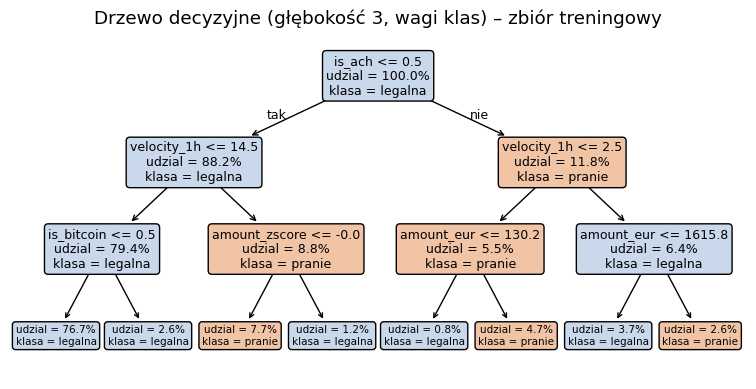

In [ ]:
# Drzewo decyzyjne (CART) o glebokośc 3
cechy_drzewa = ['amount_eur', 'same_bank', 'same_currency', 'is_ach', 'is_cheque', 'is_bitcoin',
                'velocity_1h', 'fanout_1d', 'fanin_1d', 'account_activity', 'amount_zscore',
                'round_trip', 'hour']
X_train_drzewo = df.loc[X_train.index, cechy_drzewa]
X_test_drzewo = df.loc[X_test.index, cechy_drzewa]

drzewo = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=1)
drzewo.fit(X_train_drzewo, y_train)
y_pred_drzewo = drzewo.predict(X_test_drzewo)
y_score_drzewo = drzewo.predict_proba(X_test_drzewo)[:, 1]
results['drzewo'] = evaluate('Drzewo decyzyjne (max_depth=3, class_weight=balanced)', y_test, y_pred_drzewo, y_score_drzewo)

# reguly drzewa w postaci tekstu
print(export_text(drzewo, feature_names=cechy_drzewa, decimals=2))

# ile transakcji i jaki odsetek prania jest w kazdym liściu drzewa (zbior testowy)
lisc = drzewo.apply(X_test_drzewo)
tabela_lisci = pd.crosstab(lisc, y_test)
tabela_lisci.columns = ['legalne', 'pranie']
tabela_lisci['odsetek prania [%]'] = tabela_lisci['pranie'] / (tabela_lisci['legalne'] + tabela_lisci['pranie']) * 100
tabela_lisci['klasa w lisciu'] = pd.Series(y_pred_drzewo).groupby(lisc).first()
print(tabela_lisci.round(3).to_string())

# rysunek drzewa (Rysunek 6)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
wezly = plot_tree(drzewo, feature_names=cechy_drzewa, class_names=['legalna', 'pranie'], filled=True,
                  rounded=True, impurity=False, proportion=True, precision=1, fontsize=9, ax=ax)
# polskie opisy w wezlach i kolory jak na pozostalych wykresach (niebieski - legalna, pomaranczowy - pranie pieniędzy
for wezel in wezly:
    tekst = wezel.get_text()
    if wezel.get_bbox_patch() is None:
        # napisy "True"/"False" przy galeziach pierwszego podziału
        wezel.set_text('tak' if tekst.strip() == 'True' else 'nie')
        continue

 
    linie = [w for w in tekst.split('\n') if not w.startswith('value')]
    tekst = '\n'.join(linie).replace('samples', 'udzial').replace('class', 'klasa')
    wezel.set_text(tekst)
    if '<=' not in tekst:
        # lisc (nie ma warunku podziału) - liści jest osiem obok siebie (stosuję mniejsza czcionka)
        wezel.set_fontsize(7.5)
    if 'klasa = pranie' in tekst:
        wezel.get_bbox_patch().set_facecolor('#F2C4A6')
    else:
        wezel.get_bbox_patch().set_facecolor('#C9D8EA')
ax.set_title('Drzewo decyzyjne (głębokość 3, wagi klas) – zbiór treningowy')
plt.savefig('rysunki/rys06_drzewo.png', dpi=200, bbox_inches='tight')
plt.show()

In [67]:
# Random Forest - drugi model ML zdolny wychwytywać interakcje miedzy cechami (np. "duza kwota oraz wysoka czestotliwosc" moze byc bardziej podejrzane niż każda z cech osobno) 
# class_weight='balanced_subsample' działa podobnie jak 'balanced' w regresji,
# max_depth i min_samples_leaf ograniczają złożoność pojedynczych drzew, żeby model sie nie przeuczył na dużym zbiorze.
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=5,
                             class_weight='balanced_subsample', n_jobs=-1, random_state=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]
print(f"Czas trenowania Random Forest: {time.time()-t0:.1f}s\n")
results['rf'] = evaluate('Random Forest (class_weight=balanced_subsample)', y_test, y_pred_rf, y_score_rf)

Czas trenowania Random Forest: 263.6s

--- Random Forest (class_weight=balanced_subsample) ---
Macierz pomylek:
[[1439902   82049]
 [    228    1325]]
Accuracy: 0.945995
Precision: 0.0159  Recall: 0.8532  F1: 0.0312  ROC-AUC: 0.9796



In [69]:
# Zestawienie wynikow modeli na zbiorze testowym (Tabela 7), w procentach
tabela_modeli = pd.DataFrame(list(results.values())).set_index('name')
print((tabela_modeli * 100).round(2).to_string())

                                                       accuracy  precision  recall    f1  roc_auc
name                                                                                             
Regresja logistyczna (bez wagowania klas)                 99.90       0.00    0.00  0.00    96.25
Regresja logistyczna (class_weight=balanced)              86.08       0.68   93.56  1.35    96.39
Drzewo decyzyjne (max_depth=3, class_weight=balanced)     85.08       0.65   95.11  1.28    95.63
Random Forest (class_weight=balanced_subsample)           94.60       1.59   85.32  3.12    97.96


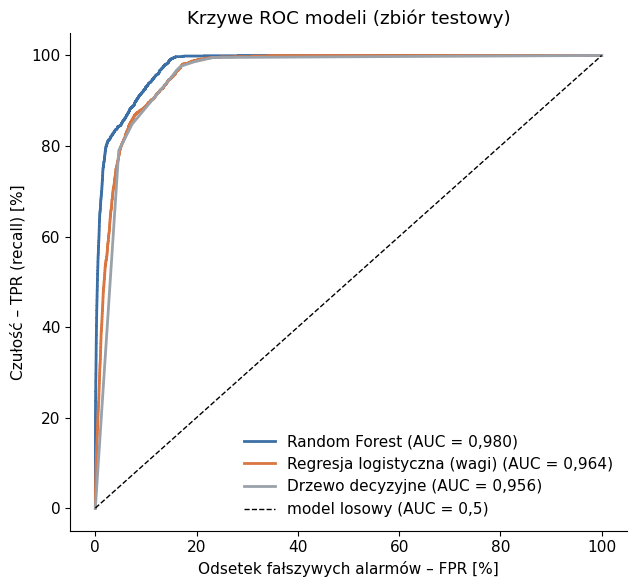

In [71]:
# Krzywe ROC (Rysunek 7)
fig, ax = plt.subplots(figsize=(6.5, 6))
for nazwa, score, kolor in [('Random Forest', y_score_rf, BLUE),
                            ('Regresja logistyczna (wagi)', y_score_lr, ORANGE),
                            ('Drzewo decyzyjne', y_score_drzewo, GRAY)]:
    fpr, tpr, progi_roc = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    ax.plot(fpr * 100, tpr * 100, color=kolor, linewidth=2,
            label=f"{nazwa} (AUC = {auc:.3f})".replace('.', ','))
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1, label='model losowy (AUC = 0,5)')
ax.set_xlabel('Odsetek fałszywych alarmów – FPR [%]')
ax.set_ylabel('Czułość – TPR (recall) [%]')
ax.set_title('Krzywe ROC modeli (zbiór testowy)')
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
plt.savefig('rysunki/rys07_krzywe_roc.png', dpi=200, bbox_inches='tight')
plt.show()

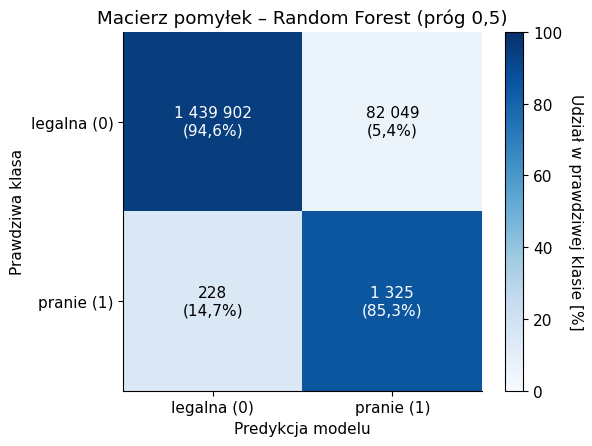

In [73]:
# Macierz pomyłek Random Forest (Rysunek 8) - mapa ciepła
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_proc = cm_rf / cm_rf.sum(axis=1, keepdims=True) * 100   # udział w  prawdziwej klasie
fig, ax = plt.subplots(figsize=(6, 4.6))
im = ax.imshow(cm_proc, cmap='Blues', vmin=0, vmax=100)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Udział w prawdziwej klasie [%]', rotation=-90, va='bottom')
ax.set_xticks(np.arange(2), labels=['legalna (0)', 'pranie (1)'])
ax.set_yticks(np.arange(2), labels=['legalna (0)', 'pranie (1)'])
ax.set_xlabel('Predykcja modelu')
ax.set_ylabel('Prawdziwa klasa')
for i in range(2):
    for j in range(2):
        tekst = f"{cm_rf[i, j]:,}".replace(',', ' ') + f"\n({cm_proc[i, j]:.1f}%)".replace('.', ',')
        ax.text(j, i, tekst, ha='center', va='center', color='white' if cm_proc[i, j] > 50 else 'black')
ax.set_title('Macierz pomyłek – Random Forest (próg 0,5)')
fig.tight_layout()
plt.savefig('rysunki/rys08_macierz_pomylek.png', dpi=200, bbox_inches='tight')
plt.show()

is_ach              0.388936
amount_log          0.140045
velocity_1h         0.106917
account_activity    0.101126
is_cheque           0.065835
fanout_1d           0.054369
amount_zscore       0.036860
fanin_1d            0.036837
same_bank           0.025973
hour                0.019743
round_trip          0.015172
same_currency       0.004720
is_bitcoin          0.003469
dtype: float64


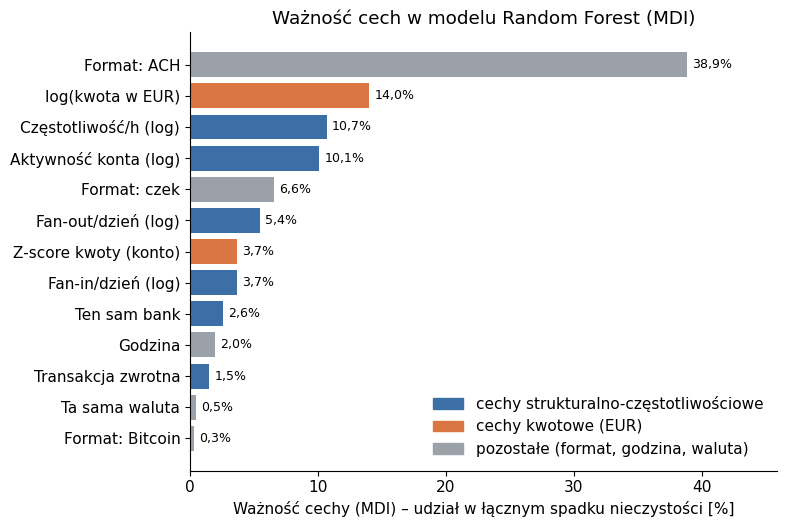


Suma waznosci cech kwotowych:    0.1769
Suma waznosci cech strukturalnych/czestotliwosciowych: 0.3404
Suma waznosci pozostalych cech:  0.4827


In [75]:
# Ważność cech Random Forest (Rysunek 9) - używam wbudowanej miary MDI (Mean Decrease in Impurity),
# czyli średniego spadku nieczystości węzłów drzewa dzieki podziałowi wg danej cechy, zsumowanego po wszystkich drzewach.
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

# Grupy cech do testu hipotezy H3 - na wykresie kolor slupka = grupa cechy
amount_feats = ['amount_log', 'amount_zscore']
structure_feats = ['velocity_1h', 'fanout_1d', 'fanin_1d', 'account_activity', 'round_trip', 'same_bank']

nazwy_cech = {'is_ach': 'Format: ACH', 'is_cheque': 'Format: czek', 'is_bitcoin': 'Format: Bitcoin',
              'amount_log': 'log(kwota w EUR)', 'amount_zscore': 'Z-score kwoty (konto)',
              'velocity_1h': 'Częstotliwość/h (log)', 'fanout_1d': 'Fan-out/dzień (log)',
              'fanin_1d': 'Fan-in/dzień (log)', 'account_activity': 'Aktywność konta (log)',
              'round_trip': 'Transakcja zwrotna', 'same_bank': 'Ten sam bank',
              'same_currency': 'Ta sama waluta', 'hour': 'Godzina'}

imp_sorted = importances.sort_values()   # od najmniejszej - najważniejsza cecha będzie na górze wykresu
kolory = []
for c in imp_sorted.index:
    if c in structure_feats:
        kolory.append(BLUE)
    elif c in amount_feats:
        kolory.append(ORANGE)
    else:
        kolory.append(GRAY)

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.barh([nazwy_cech[c] for c in imp_sorted.index], imp_sorted.values * 100, color=kolory)
for i, v in enumerate(imp_sorted.values * 100):
    ax.text(v + 0.4, i, f"{v:.1f}%".replace('.', ','), va='center', fontsize=9)
ax.set_xlim(0, imp_sorted.max() * 100 * 1.18)
ax.set_xlabel('Ważność cechy (MDI) – udział w łącznym spadku nieczystości [%]')
ax.set_title('Ważność cech w modelu Random Forest (MDI)')
ax.legend(handles=[Patch(color=BLUE, label='cechy strukturalno-częstotliwościowe'),
                   Patch(color=ORANGE, label='cechy kwotowe (EUR)'),
                   Patch(color=GRAY, label='pozostałe (format, godzina, waluta)')],
          frameon=False, loc='lower right')
fig.tight_layout()
plt.savefig('rysunki/rys09_waznosc_mdi.png', dpi=200, bbox_inches='tight')
plt.show()

# Test hipotezy H3: czy cechy czestotliwościowe (jak czesto/z iloma kontami dane konto sie kontaktuje) maja wieksze znaczenie niz cechy dotyczace samej kwoty transakcji - sumujemy waznośći osobno dla obu grup i porównujemy.
print()
print("Suma waznosci cech kwotowych:   ", round(importances[amount_feats].sum(), 4))
print("Suma waznosci cech strukturalnych/czestotliwosciowych:", round(importances[structure_feats].sum(), 4))
print("Suma waznosci pozostalych cech: ", round(importances.drop(amount_feats + structure_feats).sum(), 4))

**Obserwacja:** format ACH pozostaje najsilniejszym pojedynczym predyktorem (38,9% ważności MDI),
a drugie miejsce zajmuje logarytm kwoty w EUR (14,0%). Dla hipotezy H3 istotne są sumy grup: cechy
strukturalno-częstotliwościowe mają łącznie 34,0% ważności, a cechy kwotowe – 17,7%, czyli prawie
dwa razy mniej. **Hipoteza H3 zostaje potwierdzona.**

In [77]:
# Sprawdzam które rzeczywiste przypadki prania pieniędzy Random Forest pomija (blad falszywie negatywny, FN) przy progu 0.5
# i czym różnią się od przypadkow wykrytych (TP)? Używam predykcji policzonych wczesniej (y_pred_rf).
fn_mask = (y_test == 1) & (y_pred_rf == 0)
tp_mask = (y_test == 1) & (y_pred_rf == 1)
print("Liczba FN (pominietych):", int(fn_mask.sum()), " Liczba TP (wykrytych):", int(tp_mask.sum()))

# profil obu grup - cechy w "normalnych" jednostkach (z df, a nie z X_test, gdzie sa po logarytmie)
fn_df = df.loc[X_test.index[fn_mask.values]]
tp_df = df.loc[X_test.index[tp_mask.values]]
profil = pd.DataFrame({
    'FN (pominiete)': [fn_df['is_ach'].mean() * 100, (1 - fn_df['same_bank'].mean()) * 100,
                       fn_df['velocity_1h'].median(), fn_df['fanout_1d'].median(),
                       fn_df['account_activity'].median(), fn_df['amount_eur'].median()],
    'TP (wykryte)': [tp_df['is_ach'].mean() * 100, (1 - tp_df['same_bank'].mean()) * 100,
                     tp_df['velocity_1h'].median(), tp_df['fanout_1d'].median(),
                     tp_df['account_activity'].median(), tp_df['amount_eur'].median()]},
    index=['udzial ACH [%]', 'udzial transakcji miedzybankowych [%]', 'mediana velocity_1h [transakcje/h]',
           'mediana fanout_1d [odbiorcy/dzien]', 'mediana aktywnosci konta [transakcje]', 'mediana kwoty [EUR]'])
print(profil.round(2).to_string())
print("\nMediana prognozy modelu (score) dla przypadkow FN:", round(float(np.median(y_score_rf[fn_mask.values])), 4))
print("Odsetek FN ze score >= 0.2:", round(float((y_score_rf[fn_mask.values] >= 0.2).mean()), 4))
del fn_df, tp_df

Liczba FN (pominietych): 228  Liczba TP (wykrytych): 1325
                                       FN (pominiete)  TP (wykryte)
udzial ACH [%]                                  25.00         97.28
udzial transakcji miedzybankowych [%]           98.68         98.11
mediana velocity_1h [transakcje/h]              71.50          2.00
mediana fanout_1d [odbiorcy/dzien]             867.00          2.00
mediana aktywnosci konta [transakcje]        14174.00         10.00
mediana kwoty [EUR]                           1542.68       6400.34

Mediana prognozy modelu (score) dla przypadkow FN: 0.368
Odsetek FN ze score >= 0.2: 0.8114


**Obserwacja:** wśród wykrytych przypadków prania (TP) 97,3% to transakcje ACH, a wśród
pominiętych (FN) – tylko 25%. Pominięte przypadki pochodzą z bardzo aktywnych kont (mediana 14 174
transakcji wobec 10 w grupie TP; fan-out 867 wobec 2 odbiorców dziennie) i mają niższe kwoty (mediana
1 543 EUR wobec 6 400 EUR). Model najlepiej rozpoznaje dominujący wzorzec prania w zbiorze (pojedynczy
przelew ACH z mało aktywnego konta) i gubi przypadki ukryte w masie transakcji bardzo aktywnych
rachunków. Dla 81% pominiętych przypadków score wynosi co najmniej 0,2, więc obniżenie progu
odcięcia pozwoliłoby wykryć część z nich kosztem większej liczby alertów.

## 5. Porównanie reguł i modeli ML (H1, H2)

Reguły dają twardą decyzję 0/1, a modele – prawdopodobieństwo prania (score), z którego alert
powstaje dopiero po wyborze progu odcięcia (cut-off). Dlatego porównanie przeprowadzono na dwa
sposoby, na tym samym zbiorze testowym: **H1** – przy tej samej liczbie alertów (model generuje
dokładnie tyle alertów co reguły), **H2** – tabela cut-off: precyzja i recall modeli przy progach
0,5 / 0,7 / 0,9 / 0,95 (jak w skrypcie `cut_off.R` z zajęć) w zestawieniu z precyzją i recall reguł.

In [79]:
# Wyniki modeli ML (score) i flagi regul dla tych samych transakcji ze zbioru testowego
test = df.loc[X_test.index, rule_cols + ['RULE_ALERT', 'Is Laundering']].copy()
test['score_rf'] = y_score_rf
test['score_lr'] = y_score_lr
n_test = len(test)
n_pos = int(test['Is Laundering'].sum())
print(f"Zbior testowy: {n_test} transakcji, {n_pos} przypadkow prania ({n_pos / n_test:.4%})")

# H1: połączenie reguł (OR) vs ML przy takiej samej liczbie alertów (Tabela 8)
k = int(test['RULE_ALERT'].sum())
tp_regul = int(((test['RULE_ALERT'] == 1) & (test['Is Laundering'] == 1)).sum())
print(f"\nReguly (OR, wszystkie 5): alerty = {k} ({k / n_test:.2%} transakcji) | TP = {tp_regul} | "
      f"recall = {tp_regul / n_pos:.2%}")
for nazwa, kolumna in [('Random Forest', 'score_rf'), ('Regresja logistyczna', 'score_lr')]:
    prog_k = np.sort(test[kolumna].values)[::-1][k - 1]
    alert = test[kolumna] >= prog_k
    tp = int((alert & (test['Is Laundering'] == 1)).sum())
    print(f"{nazwa:24s}: prog cut-off = {prog_k:.4f} | alerty = {int(alert.sum())} | TP = {tp} | "
          f"recall = {tp / n_pos:.2%}")

# to samo przy budżecie każdej reguły osobno - Sprawdzam czy ML wykrywa wiecej przy budżecie pojedynczej reguly
wiersze = []
for regula in rule_cols:
    k_r = int(test[regula].sum())
    wiersz = {'regula': regula, 'alerty': k_r, 'budzet [%]': k_r / n_test * 100,
              'recall reguly [%]': ((test[regula] == 1) & (test['Is Laundering'] == 1)).sum() / n_pos * 100}
    for nazwa, kolumna in [('RF', 'score_rf'), ('LR', 'score_lr')]:
        prog_k = np.sort(test[kolumna].values)[::-1][k_r - 1]
        wiersz['recall ' + nazwa + ' [%]'] = ((test[kolumna] >= prog_k) & (test['Is Laundering'] == 1)).sum() / n_pos * 100
    wiersze.append(wiersz)
porownanie_regul = pd.DataFrame(wiersze).set_index('regula')
print()
print(porownanie_regul.round(2).to_string())

Zbior testowy: 1523504 transakcji, 1553 przypadkow prania (0.1019%)

Reguly (OR, wszystkie 5): alerty = 327476 (21.49% transakcji) | TP = 1511 | recall = 97.30%
Random Forest           : prog cut-off = 0.0256 | alerty = 327480 | TP = 1551 | recall = 99.87%
Regresja logistyczna    : prog cut-off = 0.0852 | alerty = 327476 | TP = 1541 | recall = 99.23%

                 alerty  budzet [%]  recall reguly [%]  recall RF [%]  recall LR [%]
regula                                                                              
R1_duza_kwota     15323        1.01               2.12          65.55          32.90
R2_structuring    27548        1.81              10.17          76.56          50.35
R3_velocity      137541        9.03              11.91          91.37          87.89
R4_fanout        134915        8.86              11.91          91.18          87.83
R5_kanal_ryzyka  155213       10.19              84.93          93.24          89.05


In [81]:
# H2: precyzja i recall modeli przy różnych progach odcięcia (cut-off)(Tabela 9)
CUT_OFFS = [0.5, 0.7, 0.9, 0.95]
wyniki_cutoff = []
for nazwa, skrot, score in [('Regresja logistyczna', 'LR', y_score_lr), ('Drzewo decyzyjne', 'Drzewo', y_score_drzewo),
                            ('Random Forest', 'RF', y_score_rf)]:
    for cut_off in CUT_OFFS:
        predykcja = (score > cut_off).astype(int)
        wynik = metrics(predykcja, y_test.values, f"{skrot} cut-off {cut_off}")
        wynik['model'] = nazwa
        wynik['cut_off'] = cut_off
        wyniki_cutoff.append(wynik)
    print()

# dla porownania - reguly na tym samym zbiorze testowym
wyniki_regul_test = [metrics(test[c].values, test['Is Laundering'].values, c) for c in rule_cols + ['RULE_ALERT']]

# zestawienie (Tabela 9): modele przy progach cut-off, precision i recall w procentach
tabela_cutoff = pd.DataFrame(wyniki_cutoff)[['model', 'cut_off', 'alerty', 'TP', 'precision', 'recall']]
tabela_cutoff['precision'] = tabela_cutoff['precision'] * 100
tabela_cutoff['recall'] = tabela_cutoff['recall'] * 100
print()
print(tabela_cutoff.round(2).to_string(index=False))

LR cut-off 0.5       | alerty=  213398 | TP= 1453 FP=  211945 FN=  100 | precision=0.0068 recall=0.9356 F1=0.0135
LR cut-off 0.7       | alerty=  117395 | TP= 1342 FP=  116053 FN=  211 | precision=0.0114 recall=0.8641 F1=0.0226
LR cut-off 0.9       | alerty=   51391 | TP= 1059 FP=   50332 FN=  494 | precision=0.0206 recall=0.6819 F1=0.0400
LR cut-off 0.95      | alerty=   17481 | TP=  578 FP=   16903 FN=  975 | precision=0.0331 recall=0.3722 F1=0.0607

Drzewo cut-off 0.5   | alerty=  228727 | TP= 1477 FP=  227250 FN=   76 | precision=0.0065 recall=0.9511 F1=0.0128
Drzewo cut-off 0.7   | alerty=   71604 | TP= 1227 FP=   70377 FN=  326 | precision=0.0171 recall=0.7901 F1=0.0335
Drzewo cut-off 0.9   | alerty=   71604 | TP= 1227 FP=   70377 FN=  326 | precision=0.0171 recall=0.7901 F1=0.0335
Drzewo cut-off 0.95  | alerty=       0 | TP=    0 FP=       0 FN= 1553 | precision=0.0000 recall=0.0000 F1=0.0000

RF cut-off 0.5       | alerty=   83374 | TP= 1325 FP=   82049 FN=  228 | precision=0.0

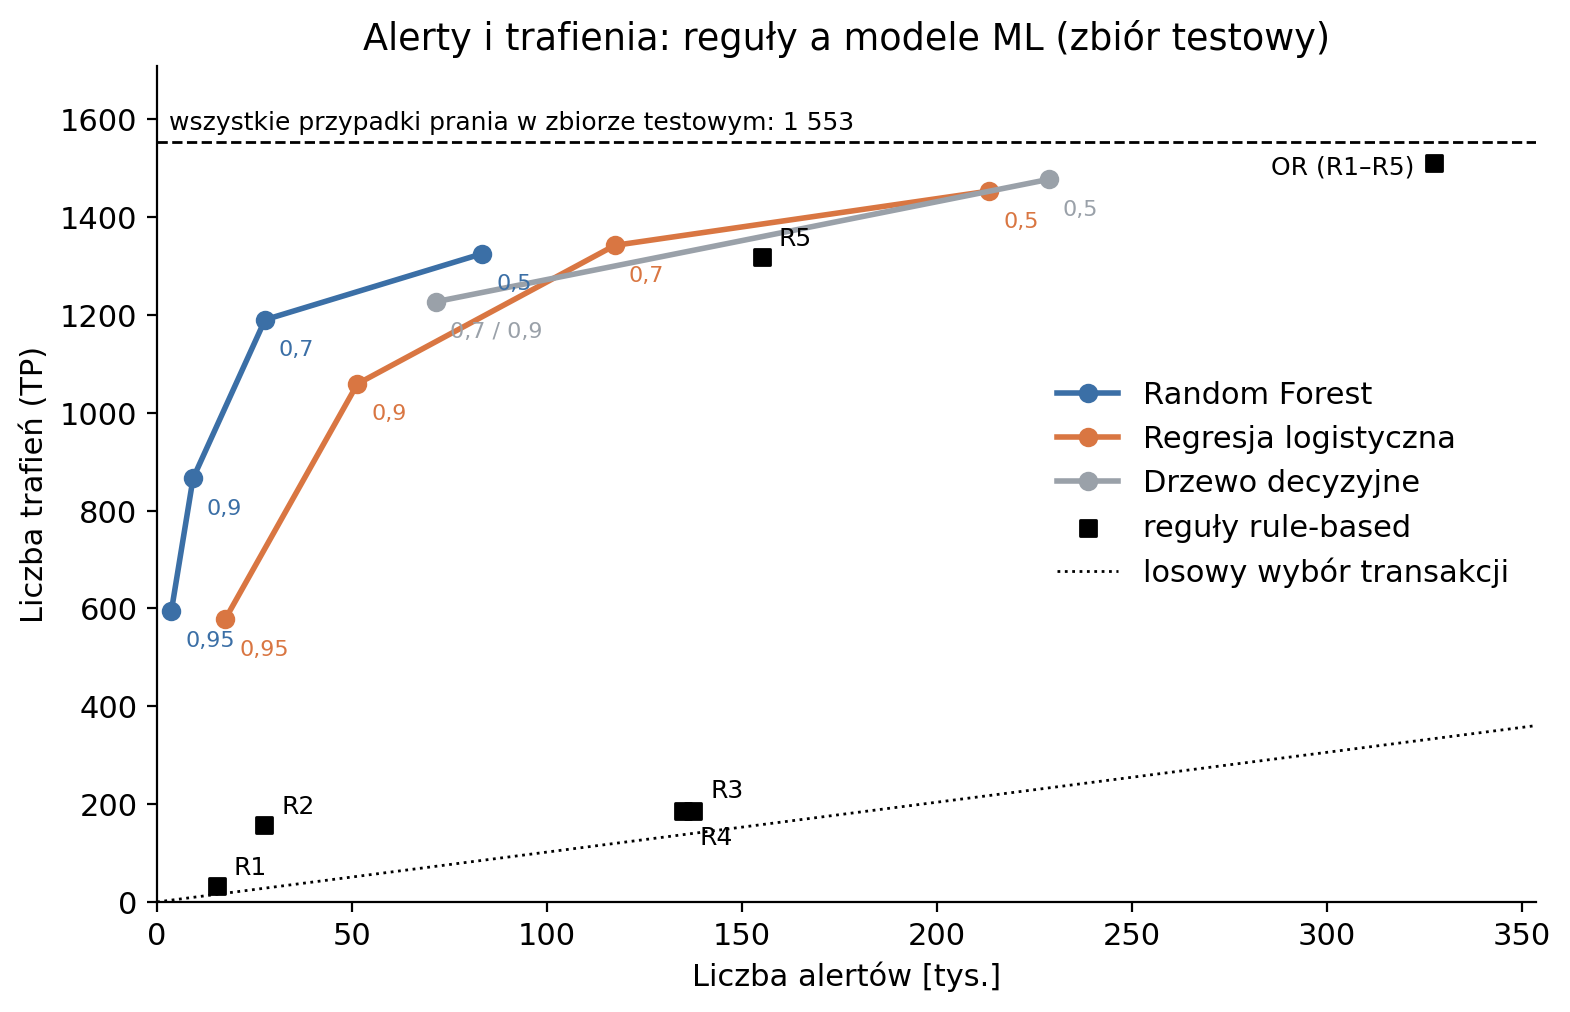

In [ ]:
# Liczba alertow i trafien (TP) regul i modeli ML na zbiorze testowym. Każda reguła to jeden punkt, a każdy model - linia łącząca wyniki przy progach cut-off z Tabeli 9.

fig, ax = plt.subplots(figsize=(8, 5.2))
for nazwa, kolor in [('Random Forest', BLUE), ('Regresja logistyczna', ORANGE), ('Drzewo decyzyjne', GRAY)]:
    punkty = tabela_cutoff[(tabela_cutoff['model'] == nazwa) & (tabela_cutoff['alerty'] > 0)]
    # progi dajace ten sam wynik (drzewo: 0,7 i 0,9) lacze w jeden punkt z podwojnym opisem
    punkty = punkty.groupby(['alerty', 'TP'], as_index=False)['cut_off'].agg(
        lambda p: ' / '.join(f"{v:g}".replace('.', ',') for v in p)).sort_values('alerty')
    ax.plot(punkty['alerty'] / 1000, punkty['TP'], color=kolor, marker='o', linewidth=2, label=nazwa)
    for _, w in punkty.iterrows():
        ax.annotate(w['cut_off'], (w['alerty'] / 1000, w['TP']), textcoords='offset points',
                    xytext=(5, -13), fontsize=8, color=kolor)
# reguly R1-R5 i ich polaczenie OR - pojedyncze punkty (czarne kwadraty)
opisy_regul = {'R1_duza_kwota': ('R1', (6, 4), 'left'), 'R2_structuring': ('R2', (6, 4), 'left'),
               'R3_velocity': ('R3', (6, 5), 'left'), 'R4_fanout': ('R4', (6, -12), 'left'),
               'R5_kanal_ryzyka': ('R5', (6, 4), 'left'), 'RULE_ALERT': ('OR (R1–R5)', (-7, -4), 'right')}
for w in wyniki_regul_test:
    opis, przesuniecie, wyrownanie = opisy_regul[w['regula']]
    ax.scatter(w['alerty'] / 1000, w['TP'], color='black', marker='s', s=36, zorder=3)
    ax.annotate(opis, (w['alerty'] / 1000, w['TP']), textcoords='offset points', xytext=przesuniecie,
                ha=wyrownanie, fontsize=9)
ax.scatter([], [], color='black', marker='s', s=36, label='reguły rule-based')
# punkt odniesienia: losowy wybor transakcji (liczba trafien = odsetek prania x liczba alertow)
x_max = test['RULE_ALERT'].sum() * 1.08
ax.plot([0, x_max / 1000], [0, x_max * n_pos / n_test], color='black', linestyle=':', linewidth=1,
        label='losowy wybór transakcji')
ax.axhline(n_pos, color='black', linestyle='--', linewidth=1)
ax.text(3, n_pos + 25, f"wszystkie przypadki prania w zbiorze testowym: {n_pos:,}".replace(',', ' '), fontsize=9)
ax.set_xlim(0, x_max / 1000)
ax.set_ylim(0, n_pos * 1.1)
ax.set_xlabel('Liczba alertów [tys.]')
ax.set_ylabel('Liczba trafień (TP)')
ax.set_title('Alerty i trafienia: reguły a modele ML (zbiór testowy)')
ax.legend(frameon=False, loc='center right')
fig.tight_layout()
plt.savefig('rysunki/rys10_alerty_trafienia.png', dpi=200, bbox_inches='tight')
plt.show()

Opis: Im wyzej na wykresie przy tej samej liczbie alertow, tym wiecej wykrytych przypadkow prania. Im bardziej w lewo przy tej samej liczbie trafień, tym mniej fałszywych alarmów.

**H1 (ML osiąga wyższy recall niż reguły przy takiej samej liczbie alertów): potwierdzona.**
Przy budżecie połączenia reguł (327 476 alertów, 21,49% transakcji testowych) Random Forest wykrywa
99,87%, a regresja logistyczna 99,23% przypadków prania, wobec 97,30% dla reguł. Przewaga jest
znacznie większa przy mniejszych budżetach: przy budżecie reguły R1 (1,0% transakcji) Random Forest
wykrywa 65,6% przypadków, a reguła 2,1%; przy budżecie R2 (1,8%) – 76,6% wobec 10,2%; przy budżecie
R5 (10,2%) – 93,2% wobec 84,9%.

**H2 (reguły mają wyższą precyzję przy niskiej czułości – recall ≤ 40% – a przewaga maleje wraz ze wzrostem recall):
niepotwierdzona.** Przy każdym badanym progu odcięcia Random Forest ma wyższą precyzję niż każda
z reguł: przy progu 0,95 wykrywa 38,3% przypadków z precyzją 16,2%, a przy progu 0,5 – 85,3%
z precyzją 1,6%, podczas gdy precyzja reguł nie przekracza 0,85% (R5, recall 84,9%). Regresja
logistyczna przy progu 0,95 ma precyzję 3,3% przy recall 37,2%. Drzewo decyzyjne ma tylko 8 różnych
wartości score (po jednej na liść), dlatego progi 0,7 i 0,9 dają ten sam wynik (precyzja 1,7%,
recall 79,0%), a przy progu 0,95 drzewo nie generuje żadnego alertu.

## Podsumowanie

Wyniki z notebooka są podstawą rozdziału 4 pracy („Implementacja i wyniki”):

| Sekcja notebooka | Element pracy |
|---|---|
| 1. EDA – rozkład klas, formaty płatności, waluty | Rysunek 2, Rysunek 3, Tabela 1 |
| 1a. Kursy NBP i Binance, przeliczenie kwot na EUR | Tabela 2 |
| 1b. Rozkład kwot w EUR | Tabela 3, Rysunki 4–5 |
| 3. Reguły R1–R5, pokrycie reguł | Tabele 4–5 |
| 3a. Progi z przepisów P1–P5 | Tabela 6 |
| 4. Modele ML: wyniki, drzewo decyzyjne, krzywe ROC, macierz pomyłek, ważność cech (H3), przypadki FN | Tabela 7, Rysunki 6–9 |
| 5. Porównanie przy tym samym budżecie alertów (H1) i tabela cut-off (H2) | Tabele 8–9, Rysunek 10 |

Hipotezy: **H1 – potwierdzona**, **H2 – niepotwierdzona**, **H3 – potwierdzona**.